# LangGraph 기본 문제: 그래프 설계하기 - 정답본

이 노트북은 학생용 문제의 정답 코드가 포함된 버전이다.

# LangGraph 기본 문제: 그래프 설계하기

이 노트북의 목표는 **LangGraph의 그래프를 직접 설계할 수 있는지 확인하는 것**이다.

학생은 검색, 요약, 검증, 검색어 재작성, 리포트 작성 함수의 내부 구현을 수정하지 않는다.  
이미 제공된 노드 함수를 사용해 **StateGraph에 노드를 등록하고 Edge를 연결하는 부분만 완성**한다.

## 완성해야 할 그래프

```mermaid
flowchart TD
    START([START]) --> SEARCH[검색]
    SEARCH --> SUMMARY[요약]
    SUMMARY --> VERIFY[검증]

    VERIFY -->|충분함| REPORT[리포트작성]
    VERIFY -->|부족함 + 검색횟수 남음| REWRITE[검색어재작성]
    VERIFY -->|최대 검색횟수 도달| REPORT

    REWRITE --> SEARCH
    REPORT --> END([END])
```

## 학습 목표

1. `StateGraph`를 생성할 수 있다.
2. 노드 함수를 그래프에 등록할 수 있다.
3. `START`와 `END`를 포함한 기본 Edge를 연결할 수 있다.
4. `add_conditional_edges()`를 사용해 조건부 분기를 만들 수 있다.
5. `검색어재작성 → 검색` 재검색 루프를 설계할 수 있다.
6. 최대 검색 횟수 조건을 사용해 무한 루프를 방지할 수 있다.


## 문제 상황

사용자가 입력한 주제에 대해 다음 흐름으로 뉴스 브리핑 그래프를 설계한다.

1. `검색` 노드에서 검색 결과를 만든다.
2. `요약` 노드에서 검색 결과를 요약한다.
3. `검증` 노드에서 요약 결과가 충분한지 판단한다.
4. 충분하면 `리포트작성` 노드로 이동한다.
5. 부족하면 `검색어재작성` 노드로 이동한 뒤 다시 `검색` 노드로 돌아간다.
6. 단, 검색 횟수가 3회에 도달하면 부족하더라도 `리포트작성` 노드로 이동한다.

## 제공 노드

| 노드 이름 | 역할 | 학생 수정 여부 |
|---|---|---|
| `검색` | 검색어를 기준으로 뉴스 검색 결과를 만든다. | 수정하지 않음 |
| `요약` | 검색 결과를 기사별 요약으로 변환한다. | 수정하지 않음 |
| `검증` | 요약 결과가 충분한지 판단한다. | 수정하지 않음 |
| `검색어재작성` | 검색 결과가 부족할 때 검색어를 바꾼다. | 수정하지 않음 |
| `리포트작성` | 최종 뉴스 브리핑을 만든다. | 수정하지 않음 |


In [3]:
# 필요 시 설치한다.
# uv add langgraph typing_extensions

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

MAX_SEARCH_COUNT = 3


In [4]:
class SimpleNewsState(TypedDict):
    # 사용자가 입력한 원래 주제
    topic: str

    # 현재 검색어
    search_query: str

    # 검색 결과 목록
    search_results: list[dict]

    # 기사별 요약 목록
    summaries: list[dict]

    # 요약 결과가 충분한지 여부
    is_sufficient: bool

    # 검증 결과에 대한 설명
    feedback: str

    # 최종 리포트
    report: str

    # 검색 횟수
    search_count: int


In [5]:
def search_node(state: SimpleNewsState) -> dict:
    """검색 노드: 검색어를 기준으로 뉴스 검색 결과를 만든다."""

    query = state.get("search_query") or state["topic"]
    search_count = state.get("search_count", 0) + 1

    print(f"[검색 #{search_count}] 검색어: {query}")

    # 첫 번째 검색은 일부러 부족하게 구성한다.
    if search_count == 1:
        results = [
            {
                "title": f"{query} 기사 1",
                "url": "https://example.com/1",
                "content": "짧은 내용"
            }
        ]

    # 두 번째 검색부터는 충분한 결과가 나오게 구성한다.
    else:
        results = [
            {
                "title": f"{query} 기사 {i}",
                "url": f"https://example.com/{i}",
                "content": "충분한 기사 내용입니다. " * 5
            }
            for i in range(1, 5)
        ]

    return {
        "search_query": query,
        "search_results": results,
        "search_count": search_count,
    }


def summarize_node(state: SimpleNewsState) -> dict:
    """요약 노드: 검색 결과를 기사별 요약으로 변환한다."""

    summaries = []

    for item in state.get("search_results", []):
        summaries.append({
            "title": item["title"],
            "url": item["url"],
            "summary": item["content"][:100]
        })

    print(f"[요약] {len(summaries)}개 기사 요약")

    return {
        "summaries": summaries
    }


def verify_node(state: SimpleNewsState) -> dict:
    """검증 노드: 유효한 기사 요약이 3개 이상인지 확인한다."""

    summaries = state.get("summaries", [])

    valid_summaries = [
        item for item in summaries
        if item.get("url") and len(item.get("summary", "")) >= 50
    ]

    is_sufficient = len(valid_summaries) >= 3

    if is_sufficient:
        feedback = "유효한 기사 요약이 3개 이상이다."
    else:
        feedback = f"유효한 기사 요약이 {len(valid_summaries)}개이다. 추가 검색이 필요하다."

    print(f"[검증] 충분 여부: {is_sufficient}")

    return {
        "is_sufficient": is_sufficient,
        "feedback": feedback,
    }


def rewrite_query_node(state: SimpleNewsState) -> dict:
    """검색어 재작성 노드: 부족한 검색 결과를 보완하기 위해 검색어를 수정한다."""

    new_query = f"{state['topic']} 최신 동향 사례"

    print(f"[검색어재작성] 새 검색어: {new_query}")

    return {
        "search_query": new_query
    }


def report_node(state: SimpleNewsState) -> dict:
    """리포트 작성 노드: 최종 뉴스 브리핑을 만든다."""

    summaries = state.get("summaries", [])

    lines = [
        f"# 뉴스 브리핑: {state['topic']}",
        "",
        f"- 마지막 검색어: {state['search_query']}",
        f"- 검색 횟수: {state['search_count']}",
        f"- 검증 결과: {state['feedback']}",
        "",
        "## 기사별 요약"
    ]

    for i, item in enumerate(summaries, start=1):
        lines.append(f"{i}. {item['title']}")
        lines.append(f"   - 요약: {item['summary']}")
        lines.append(f"   - 출처: {item['url']}")

    report = "\n".join(lines)

    print("[리포트작성] 최종 리포트 생성 완료")

    return {
        "report": report
    }


## 정답 코드

In [11]:
def route_after_verify(state: SimpleNewsState) -> str:
    """검증 결과에 따라 다음 노드를 선택한다."""

    if state["is_sufficient"]:
        return "리포트작성"

    if state.get("search_count", 0) >= MAX_SEARCH_COUNT:
        return "리포트작성"

    return "검색어재작성"


builder = StateGraph(SimpleNewsState)

# 노드 등록
builder.add_node("검색", search_node)
builder.add_node("요약", summarize_node)
builder.add_node("검증", verify_node)
builder.add_node("검색어재작성", rewrite_query_node)
builder.add_node("리포트작성", report_node)

# 기본 Edge 연결
builder.add_edge(START, "검색")
builder.add_edge("검색", "요약")
builder.add_edge("요약", "검증")

# 조건부 Edge 연결
builder.add_conditional_edges(
    "검증",
    route_after_verify,
    {
        "리포트작성": "리포트작성",
        "검색어재작성": "검색어재작성",
    }
)

# 재검색 루프 연결
builder.add_edge("검색어재작성", "검색")

# 종료 Edge 연결
builder.add_edge("리포트작성", END)

app = builder.compile()


## 완성된 그래프 Mermaid 확인

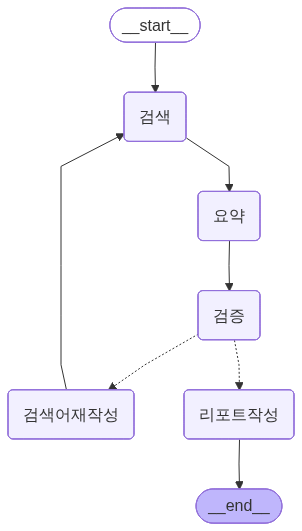

In [15]:
# 완성된 그래프의 Mermaid 코드를 출력한다.
# 환경에 따라 이미지 렌더링은 지원되지 않을 수 있다.
from IPython.display import Image, display

def show_graph(app) -> None:
    """LangGraph 구조를 시각화한다.

    Mermaid PNG 생성이 실패하면 ASCII 그래프로 대체한다.
    """
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as e:
        print(f"Mermaid 이미지 생성 실패: {e}")
        print(app.get_graph().draw_ascii())


show_graph(app)


## 실행 결과 확인

In [8]:
initial_state: SimpleNewsState = {
    "topic": "생성형 AI 교육 트렌드",
    "search_query": "",
    "search_results": [],
    "summaries": [],
    "is_sufficient": False,
    "feedback": "",
    "report": "",
    "search_count": 0,
}

result = app.invoke(initial_state)

print("\n" + "=" * 70)
print("최종 결과")
print("=" * 70)
print(result["report"])


[검색 #1] 검색어: 생성형 AI 교육 트렌드
[요약] 1개 기사 요약
[검증] 충분 여부: False
[검색어재작성] 새 검색어: 생성형 AI 교육 트렌드 최신 동향 사례
[검색 #2] 검색어: 생성형 AI 교육 트렌드 최신 동향 사례
[요약] 4개 기사 요약
[검증] 충분 여부: True
[리포트작성] 최종 리포트 생성 완료

최종 결과
# 뉴스 브리핑: 생성형 AI 교육 트렌드

- 마지막 검색어: 생성형 AI 교육 트렌드 최신 동향 사례
- 검색 횟수: 2
- 검증 결과: 유효한 기사 요약이 3개 이상이다.

## 기사별 요약
1. 생성형 AI 교육 트렌드 최신 동향 사례 기사 1
   - 요약: 충분한 기사 내용입니다. 충분한 기사 내용입니다. 충분한 기사 내용입니다. 충분한 기사 내용입니다. 충분한 기사 내용입니다. 
   - 출처: https://example.com/1
2. 생성형 AI 교육 트렌드 최신 동향 사례 기사 2
   - 요약: 충분한 기사 내용입니다. 충분한 기사 내용입니다. 충분한 기사 내용입니다. 충분한 기사 내용입니다. 충분한 기사 내용입니다. 
   - 출처: https://example.com/2
3. 생성형 AI 교육 트렌드 최신 동향 사례 기사 3
   - 요약: 충분한 기사 내용입니다. 충분한 기사 내용입니다. 충분한 기사 내용입니다. 충분한 기사 내용입니다. 충분한 기사 내용입니다. 
   - 출처: https://example.com/3
4. 생성형 AI 교육 트렌드 최신 동향 사례 기사 4
   - 요약: 충분한 기사 내용입니다. 충분한 기사 내용입니다. 충분한 기사 내용입니다. 충분한 기사 내용입니다. 충분한 기사 내용입니다. 
   - 출처: https://example.com/4


## 단계별 실행 확인

In [9]:
initial_state: SimpleNewsState = {
    "topic": "생성형 AI 교육 트렌드",
    "search_query": "",
    "search_results": [],
    "summaries": [],
    "is_sufficient": False,
    "feedback": "",
    "report": "",
    "search_count": 0,
}

for step in app.stream(initial_state):
    node_name = list(step.keys())[0]
    print(f"실행 노드: {node_name}")
    print(step[node_name])
    print("-" * 70)


[검색 #1] 검색어: 생성형 AI 교육 트렌드
실행 노드: 검색
{'search_query': '생성형 AI 교육 트렌드', 'search_results': [{'title': '생성형 AI 교육 트렌드 기사 1', 'url': 'https://example.com/1', 'content': '짧은 내용'}], 'search_count': 1}
----------------------------------------------------------------------
[요약] 1개 기사 요약
실행 노드: 요약
{'summaries': [{'title': '생성형 AI 교육 트렌드 기사 1', 'url': 'https://example.com/1', 'summary': '짧은 내용'}]}
----------------------------------------------------------------------
[검증] 충분 여부: False
실행 노드: 검증
{'is_sufficient': False, 'feedback': '유효한 기사 요약이 0개이다. 추가 검색이 필요하다.'}
----------------------------------------------------------------------
[검색어재작성] 새 검색어: 생성형 AI 교육 트렌드 최신 동향 사례
실행 노드: 검색어재작성
{'search_query': '생성형 AI 교육 트렌드 최신 동향 사례'}
----------------------------------------------------------------------
[검색 #2] 검색어: 생성형 AI 교육 트렌드 최신 동향 사례
실행 노드: 검색
{'search_query': '생성형 AI 교육 트렌드 최신 동향 사례', 'search_results': [{'title': '생성형 AI 교육 트렌드 최신 동향 사례 기사 1', 'url': 'https://example.com/1', 'content': '충분한 기사 내용

## 평가 기준

| 평가 항목 | 확인 내용 |
|---|---|
| 노드 등록 | 5개 노드가 모두 등록되었는가 |
| 기본 Edge | `START → 검색 → 요약 → 검증` 흐름이 연결되었는가 |
| 조건부 Edge | `검증` 이후 상태값에 따라 다음 노드가 달라지는가 |
| 재검색 루프 | `검색어재작성 → 검색` 흐름이 연결되었는가 |
| 종료 처리 | `리포트작성 → END` 흐름이 연결되었는가 |
| 루프 안전장치 | 최대 검색 횟수 조건이 포함되었는가 |
| 실행 결과 | 최종 State에 `report`가 생성되는가 |
